<a href="https://colab.research.google.com/github/muhammdumairnad/Price-Driven-Demand-Prediction-in-Retail-using-Machine-Learning/blob/main/Retail_Demand_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:


# Download the dataset
dataset_path = kagglehub.dataset_download("aswathrao/demand-forecasting")

# Construct the full path to the CSV filell
csv_file_path = os.path.join(dataset_path, 'train_0irEZ2H.csv')

# Read the CSV into a DataFrame
df = pd.read_csv(csv_file_path)

In [ ]:
os.listdir(dataset_path) # chk files inside aswathrao/demand-forecasting

In [ ]:
#EDA
df.head()

In [ ]:
df.shape

In [ ]:
(df==" ").sum()
#there is no null or emptu value in data set

In [ ]:
df.duplicated().sum()
# to check duplicated rows


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [8]:
#df[['day','month','year']] = df['week'].str.split('/', expand=True).astype(int) # by spliting method
#also this way
df['week'] = pd.to_datetime(df['week'])
df['day'] = df['week'].dt.day
df['month'] = df['week'].dt.month
df['year'] = df['week'].dt.year
df['day'].head()

,day
0,17
1,17
2,17
3,17
4,17


In [ ]:
df = df.drop('week', axis=1)

In [ ]:
df.isnull().sum()

In [ ]:
df['total_price'].fillna(df['base_price'], inplace=True)

In [ ]:
df['store_id'].nunique()
#there are 76 stores data

In [ ]:

df['discount'] = df['base_price'] - df['total_price']
# Fill any NaN values in discount that might arise from total_price still having NaNs before this fillna
df['discount'].fillna(0, inplace=True)

In [ ]:
df['units_sold'].sort_values(ascending=False).head()

In [ ]:
df.loc[[5607, 7917, 6762, 5559, 4917]]
# these are highly sold items. they are cheaper and discounted well. also ther are featured and displayed mostly

In [12]:
df['sku_id'].nunique()


28

In [10]:
print(df['is_featured_sku'].value_counts())
print(df['is_display_sku'].value_counts())

is_featured_sku
0    135794
1     14356
Name: count, dtype: int64
is_display_sku
0    130150
1     20000
Name: count, dtype: int64


In [13]:
df.corr()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year
record_ID,1.000000,9.536027e-01,7.464429e-03,-4.772670e-04,0.008473,0.018932,0.031358,0.020428,-0.010616,-6.319391e-02,9.035131e-02,9.296388e-01
week,0.953603,1.000000e+00,-4.693852e-14,1.176797e-14,0.009400,0.017380,0.031960,0.024487,-0.008179,-1.263960e-01,2.195069e-01,9.295573e-01
store_id,0.007464,-4.693852e-14,1.000000e+00,-6.862856e-02,-0.038315,-0.038848,-0.008729,0.013440,-0.004372,1.407103e-15,-1.035187e-15,6.712204e-15
sku_id,-0.000477,1.176797e-14,-6.862856e-02,1.000000e+00,0.119332,0.119068,-0.022255,0.014911,-0.184380,-1.023893e-15,-1.057602e-15,7.678163e-15
total_price,0.008473,9.399562e-03,-3.831516e-02,1.193319e-01,1.000000,0.958885,0.050354,-0.065930,-0.235625,-5.122607e-04,2.067740e-03,8.723508e-03
base_price,0.018932,1.737991e-02,-3.884811e-02,1.190677e-01,0.958885,1.000000,0.214333,0.051909,-0.140032,-1.186965e-03,3.855568e-03,1.611673e-02
is_featured_sku,0.031358,3.195992e-02,-8.729370e-03,-2.225491e-02,0.050354,0.214333,1.000000,0.426243,0.337751,-4.591098e-03,5.280908e-03,3.036698e-02
is_display_sku,0.020428,2.448727e-02,1.343959e-02,1.491057e-02,-0.065930,0.051909,0.426243,1.000000,0.362662,-8.585295e-03,-3.103117e-02,3.670734e-02
units_sold,-0.010616,-8.179097e-03,-4.371507e-03,-1.843798e-01,-0.235625,-0.140032,0.337751,0.362662,1.000000,-8.090324e-03,2.993099e-03,-9.180354e-03
day,-0.063194,-1.263960e-01,1.407103e-15,-1.023893e-15,-0.000512,-0.001187,-0.004591,-0.008585,-0.008090,1.000000e+00,-9.577147e-02,-1.235546e-01


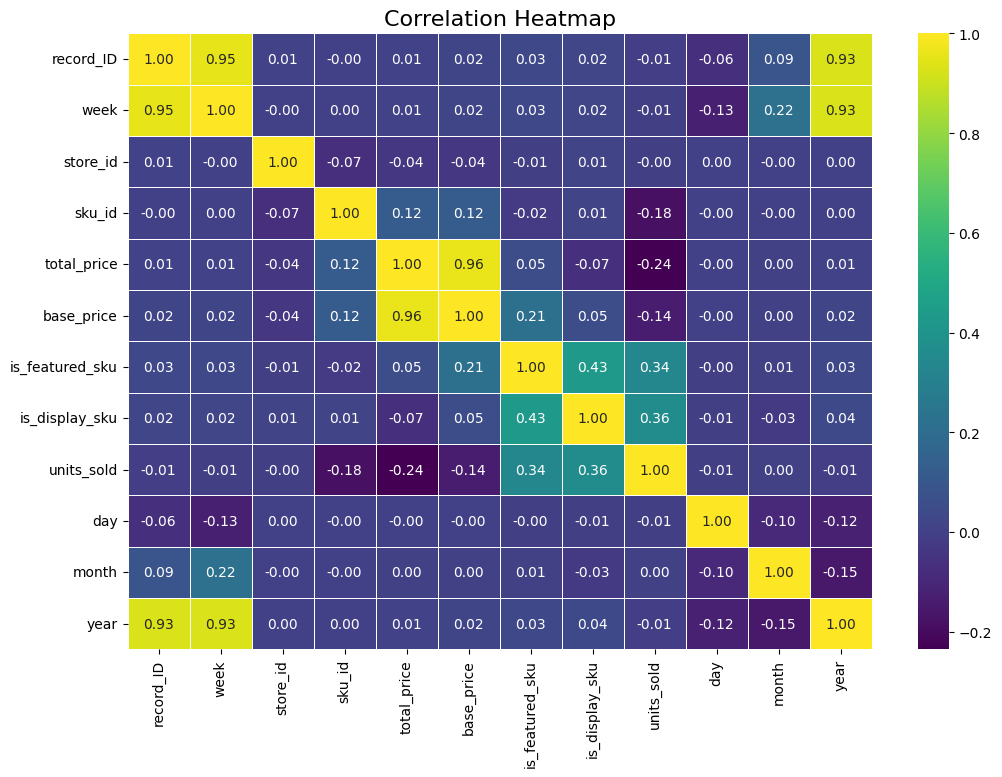

In [22]:
plt.figure(figsize=(12, 8))  # bigger heatmap

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",          # 2 decimal places
    cmap='viridis',    # color style
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=16)

plt.show()

In [ ]:
sns.scatterplot(x='total_price', y='units_sold', data=df)

# Lower price → more sales

In [ ]:
sns.scatterplot(x='discount', y='units_sold', data=df)
#more sales when discount is given

In [ ]:
df.describe()

In [ ]:
(df['discount'] < 0).sum()
df.loc[df['discount'] < 0, ['base_price', 'total_price', 'discount','units_sold']]

In [ ]:
df.loc[[70, 71, 95, 142, 143]]

In [ ]:
(df['total_price'] > df['base_price']).sum()

In [ ]:
df[df['total_price'] > df['base_price']]['units_sold'].describe()
# These represent price increases (negative discount) and may provide useful insights for model learning

In [ ]:
df.groupby('is_display_sku')['units_sold'].mean().plot(kind='bar')
# more sales for displayed items

In [ ]:
df.groupby('is_featured_sku')['units_sold'].mean().plot(kind='bar')
# more sales for featured items

In [ ]:
# record_ID → useless
# base_price → redundant (highly correlated with total_price)
df.drop(['record_ID', 'base_price'], axis=1, inplace=True)


In [ ]:
df.head()

In [ ]:
df['sku_id'] = df['sku_id'].astype('category').cat.codes

In [ ]:
df.drop('year', axis=1, inplace=True)

In [ ]:
# Month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

In [ ]:
df.drop(['month', 'day'], axis=1, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

# Drop rows with any remaining NaN values from the DataFrame
df.dropna(inplace=True)

X = df.drop('units_sold', axis=1)
y = df['units_sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [ ]:
#linear regression model
from sklearn.linear_model import LinearRegression
lg_model = LinearRegression()
lg_model.fit(X_train,y_train)

mean_squared_error_lg = mean_squared_error(y_test,lg_model.predict(X_test))
r2_score_lg = r2_score(y_test,lg_model.predict(X_test))
mean_absolute_error_lg = mean_absolute_error(y_test,lg_model.predict(X_test))

y_pred = lg_model.predict(X_test)
revenue_lg = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_lg)

print(f"Mean Squared Error: {mean_squared_error_lg}")
print(f"R2 Score: {r2_score_lg}")
print(f"Mean Absolute Error: {mean_absolute_error_lg}")




In [ ]:
#XGB Regressor Model
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
xgb = XGBRegressor()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}
xgb_model = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)
xgb_model.fit(X_train,y_train)

mean_squared_error_xgb = mean_squared_error(y_test,xgb_model.predict(X_test))
r2_score_xgb = r2_score(y_test,xgb_model.predict(X_test))
mean_absolute_error_xgb = mean_absolute_error(y_test,xgb_model.predict(X_test))

y_pred = xgb_model.predict(X_test)
revenue_xgb = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_xgb)

print(f"Mean Squared Error: {mean_squared_error_xgb}")
print(f"R2 Score: {r2_score_xgb}")
print(f"Mean Absolute Error: {mean_absolute_error_xgb}")



In [ ]:
from lightgbm import LGBMRegressor
lgbm = LGBMRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [-1, 10, 20]
}

lgbm_model = RandomizedSearchCV(
    lgbm,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
lgbm_model.fit(X_train,y_train)

mean_squared_error_lgbm = mean_squared_error(y_test,lgbm_model.predict(X_test))
r2_score_lgbm = r2_score(y_test,lgbm_model.predict(X_test))
mean_absolute_error_lgbm = mean_absolute_error(y_test,lgbm_model.predict(X_test))

y_pred = lgbm_model.predict(X_test)
revenue_lgbm = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_lgbm)

print(f"Mean Squared Error: {mean_squared_error_lgbm}")
print(f"R2 Score: {r2_score_lgbm}")
print(f"Mean Absolute Error: {mean_absolute_error_lgbm}")


In [ ]:
pip install catboost

In [ ]:
# CatBoostRegressor Model
from catboost import CatBoostRegressor

cat = CatBoostRegressor(verbose=0)

param_grid = {
    'iterations': [200, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

cat_model = RandomizedSearchCV(
    cat,
    param_grid,
    n_iter=6,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
cat_model.fit(X_train,y_train)

mean_squared_error_cat = mean_squared_error(y_test,cat_model.predict(X_test))
r2_score_cat = r2_score(y_test,cat_model.predict(X_test))
mean_absolute_error_cat = mean_absolute_error(y_test,cat_model.predict(X_test))

y_pred = cat_model.predict(X_test)
revenue_cat = (y_pred * X_test['total_price']).sum()
print("Total Revenue (Predicted):", revenue_cat)

print(f"Mean Squared Error: {mean_squared_error_cat}")
print(f"R2 Score: {r2_score_cat}")
print(f"Mean Absolute Error: {mean_absolute_error_cat}")


In [ ]:
# “Price-related features like total_price and discount are the most influential, indicating that demand is highly sensitive to pricing and promotional strategies.”

In [ ]:
results = pd.DataFrame({
    "Model": ["LR","XGB","LGBM","CAT"],
    "RMSE": [np.sqrt(mean_squared_error_lg), np.sqrt(mean_squared_error_xgb), np.sqrt(mean_squared_error_lgbm), np.sqrt(mean_squared_error_cat)],
    "R2": [r2_score_lg, r2_score_xgb, r2_score_lgbm, r2_score_cat],
    "MAE": [mean_absolute_error_lg, mean_absolute_error_xgb, mean_absolute_error_lgbm, mean_absolute_error_cat],
    "Revenue": [revenue_lg, revenue_xgb, revenue_lgbm, revenue_cat]
})


In [ ]:
print(results)

In [ ]:
import shap

best_cat = cat_model.best_estimator_

explainer = shap.Explainer(best_cat)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
#SHAP analysis showed price and discount as key drivers of demand, confirming price elasticity. Promotional features like display and featured status also had strong positive impact. SKU and store IDs appeared important but represent entity-level variance rather than actionable insights.

In [ ]:
feat_imp = pd.Series(best_cat.feature_importances_, index=X_train.columns)

top_feat = feat_imp.sort_values(ascending=False).head(20)

# Remove sku columns
top_feat = top_feat[~top_feat.index.str.contains('sku_id')]

plt.figure(figsize=(10,7))
top_feat.sort_values().plot(kind='barh')

plt.title("Top Feature Importance (Cleaned)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# “Price-related features like total_price and discount are the most influential, indicating that demand is highly sensitive to pricing and promotional strategies.”


In [ ]:
# to chk which price product sold  to make maximum revenue
def optimize_price(sample_row, model):
    prices = np.linspace(
        X_test['total_price'].min(),
        X_test['total_price'].max(),
        50
    )

    best_price = None
    max_revenue = -np.inf

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p

        pred_demand = model.predict(temp.values.reshape(1, -1))[0]
        revenue = p * pred_demand

        if revenue > max_revenue:
            max_revenue = revenue
            best_price = p

    return best_price, max_revenue


In [ ]:

sample = X_test.iloc[20]

best_price, best_revenue = optimize_price(sample, best_cat)

print("Optimal Price:", best_price)
print("Max Revenue:", best_revenue)

In [ ]:
def plot_revenue_curve(sample_row, model):
    prices = np.linspace(
    X_test['total_price'].min(),
    X_test['total_price'].max(),
    50
)
    revenues = []
    demands = []

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p

        pred_demand = model.predict(temp.values.reshape(1, -1))[0]
        revenue = p * pred_demand

        demands.append(pred_demand)
        revenues.append(revenue)

    # Plot
    plt.figure(figsize=(10,5))
    # Revenue curve
    plt.plot(prices, revenues)
    plt.xlabel("Price (scaled)")
    plt.ylabel("Revenue")
    plt.title("Revenue vs Price Curve")
    plt.show()



In [ ]:
# Call the function to plot the revenue curve
plot_revenue_curve(sample, best_cat)

In [ ]:
# peaks shows optimal prices

In [ ]:
# Price Elasticity Graph

def plot_price_elasticity(sample_row, model):
    prices = np.linspace(0.5, 1.5, 50)
    demands = []

    for p in prices:
        temp = sample_row.copy()
        temp['total_price'] = p
        pred = model.predict([temp])[0]
        demands.append(pred)

    plt.figure()
    plt.plot(prices, demands)
    plt.xlabel("Price")
    plt.ylabel("Predicted Demand")
    plt.title("Price Elasticity Curve")
    plt.show()

sample = X_test.iloc[0]
plot_price_elasticity(sample, best_cat)

In [ ]:
import joblib

# Save the best_cat model first, as it was trained earlier in the notebook
joblib.dump(best_cat, "model.pkl")

model = joblib.load("model.pkl")
# scaler = joblib.load("scaler.pkl") # No scaler was explicitly trained or saved, so this line is commented out

In [ ]:
pip install streamlit

In [ ]:
pip install joblib

In [ ]:
from google.colab import files
files.download("model.pkl")